# RQ2 — Resolution Strategies

> *How are resolution decisions distributed across conflicting chunks
> (V1, V2, CC, CB, NC, NN, Imprecise), and how does this distribution
> compare to the one reported by Ghiotto et al. for human-authored
> merges?* — PLAN.md §3 (RQ2)

Strategy labels emitted by `identify_resolution` are folded to the
seven-bucket scheme of PLAN.md §5.4 (ConcatV1V2/ConcatV2V1 → CC,
Combination → CB, "New code" → NC, "None" → NN, Postponed → Imprecise).

**Imprecise handling.** Ghiotto et al. do not have an `Imprecise`
bucket, so the distribution we report for the paper is *conditional on
chunks we could classify* (i.e., excluding `Imprecise`). For
transparency, this notebook also produces the *unconditional* view
(with `Imprecise`) and reports the fraction of chunks discarded. Two
figure variants are saved for each cut: `..._incl_imprecise` and
`..._excl_imprecise`; the `excl` variant is the one referenced from
the paper.

**Styling.** All figures in this notebook omit chart titles (the
LaTeX caption carries the label) and rely on a colour-blind-safe
palette (Okabe-Ito) combined with hatches so the strategy segments
remain distinguishable when the paper is printed in black and white.

Figures are saved to `analysis/figures/` as `.pdf` + `.png`.

In [1]:
# Ensure the project root is on sys.path so ``analysis.common`` imports
# cleanly whether the kernel was launched from the repo root or from
# inside analysis/.
import sys
from pathlib import Path

_here = Path.cwd()
for candidate in [_here, *_here.parents]:
    if (candidate / "analysis" / "common.py").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from analysis.common import (
    load_tables,
    build_chunk_frame, build_merge_frame, build_pr_frame,
    setup_style, save_fig,
    stratify, stratum_order,
    descriptive_table, strategy_distribution, imprecise_share,
    strategy_frame_for_plot, plot_strategy_stacked,
    STRATEGY_ORDER, STRATEGY_PALETTE, STRATEGY_HATCH,
    RESOLVER_ORDER, RESOLVER_PALETTE,
    PR_OUTCOME_ORDER, PR_OUTCOME_PALETTE,
    TOP_N_LANGUAGES,
)

setup_style()
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

# The canonical strategy order excluding Imprecise. Used for paper
# figures and tables, which report the distribution conditional on
# chunks being classifiable.
STRATEGY_ORDER_EXCL = [s for s in STRATEGY_ORDER if s != "Imprecise"]

## 1. Load data & build the chunk frame

In [2]:
tables = load_tables()          # dedup by (repo, merge_sha) and chunk key
chunks = build_chunk_frame(tables)
print(f"Chunks (classified, deduplicated): {len(chunks):,}")
if not chunks.empty:
    print("\nRaw strategy labels before folding:")
    print(chunks["strategy_raw"].value_counts().to_string())
    imp_share = imprecise_share(chunks)
    print(f"\nImprecise share (global): {imp_share*100:.2f}% of all classified chunks")
    print(f"Classifiable chunks (excluding Imprecise): "
          f"{(chunks['strategy'] != 'Imprecise').sum():,}")

Chunks (classified, deduplicated): 121,599

Raw strategy labels before folding:
strategy_raw
Imprecise      38556
V1             37213
V2             18618
New code        7994
Postponed       7291
Combination     6797
ConcatV1V2      3661
ConcatV2V1      1017
None             452

Imprecise share (global): 37.70% of all classified chunks
Classifiable chunks (excluding Imprecise): 75,752


## 2. Global strategy distribution

We report two views:

* **Including Imprecise** (the unconditional chunk distribution).
* **Excluding Imprecise** (the distribution among chunks the
  localization algorithm classified with confidence). This is the
  view used in the paper for comparison with Ghiotto et al.

In [3]:
chunks

,repo_full_name,pr_id,merge_sha,file_path,chunk_index,v1,base,v2,v1_loc,v2_loc,base_loc,resolution,localized_ok,resolution_loc,strategy,strategy_raw,resolver_type,full_name,agent,language,pr_task_type,state,merged_at,language_top
0,01U2/FolderScanner,3.266932e+09,5637d550a685ad8a37efd545b9b0d84990ebc5db,src/ui.py,0,def ask_user_choice():\n root = tk.Tk()\n ...,def ask_user_choice():\n root = tk.Tk()\n ...,\nclass FolderScannerApp:\n def __init__(se...,32,6,30,None,False,0,Imprecise,Imprecise,human,01U2/FolderScanner,Copilot,Python,None,open,None,Python
1,01U2/FolderScanner,3.266932e+09,5637d550a685ad8a37efd545b9b0d84990ebc5db,src/ui.py,1,extensions_frame.forget()\n ...,extensions_frame.forget(),"base_path = os.path.abspath(""."")\n...",8,32,1,None,False,0,Imprecise,Imprecise,human,01U2/FolderScanner,Copilot,Python,None,open,None,Python
2,01U2/FolderScanner,3.266932e+09,5637d550a685ad8a37efd545b9b0d84990ebc5db,src/ui.py,2,"include_files_var.trace_add(""write"", toggl...","include_files_var.trace_add(""write"", toggl...",# ---------- Toggle Input Fields -----...,2,3,1,None,False,0,Imprecise,Imprecise,human,01U2/FolderScanner,Copilot,Python,None,open,None,Python
3,01U2/FolderScanner,3.266932e+09,5637d550a685ad8a37efd545b9b0d84990ebc5db,src/ui.py,3,# Include files checkbox\n tk.Checkbutt...,# Include files checkbox\n tk.Checkbutt...,self.extensions_frame = tk.Frame(self....,10,4,8,None,False,0,Imprecise,Imprecise,human,01U2/FolderScanner,Copilot,Python,None,open,None,Python
4,01U2/FolderScanner,3.266932e+09,5637d550a685ad8a37efd545b9b0d84990ebc5db,src/ui.py,4,include_files = include_files_var....,include_files = include_files_var....,include_files = self.include_files...,5,4,3,include_files = self.include_files...,True,6,CB,Combination,human,01U2/FolderScanner,Copilot,Python,None,open,None,Python
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121594,zzfadi/toico,3.256396e+09,3b1b5dc68bdd06c20a988594b64e0c97a2983291,src/app/components/Preview.tsx,3,? 'bg-mocha-mousse/10 bo...,? 'bg-mocha-mousse/10 bo...,? 'glass-card border-2 b...,2,2,2,? 'glass-card border-2 b...,True,2,V2,V2,human,zzfadi/toico,Copilot,TypeScript,None,closed,None,TypeScript
121595,zzfadi/toico,3.256396e+09,3b1b5dc68bdd06c20a988594b64e0c97a2983291,src/app/components/Preview.tsx,4,<img\n ...,<img\n ...,"<div className=""relative...",11,20,10,"<div className=""relative...",True,21,CB,Combination,human,zzfadi/toico,Copilot,TypeScript,None,closed,None,TypeScript
121596,zzfadi/toico,3.256396e+09,3b1b5dc68bdd06c20a988594b64e0c97a2983291,src/app/components/Preview.tsx,5,"<div data-testid=""conversion-success"">...",<button\n onClick={handleDown...,"<div className=""space-y-4"">\n ...",17,36,14,"<div className=""space-y-4"">\n ...",True,38,CB,Combination,human,zzfadi/toico,Copilot,TypeScript,None,closed,None,TypeScript
121597,zzfadi/toico,3.256601e+09,70986dc48419f73eee494b93fea99d9f873c9fa5,package.json,0,"""next"": ""15.4.3"",",,"""@types/jszip"": ""^3.4.0"",\n ""jszip"": ""^...",1,3,0,"""@types/jszip"": ""^3.4.0"",\n ""jszip"": ""^...",True,3,V2,V2,human,zzfadi/toico,Copilot,TypeScript,None,closed,2025-07-25T10:32:56Z,TypeScript


In [4]:
# Conflicting merges by host agent × resolver type
ct = (
    chunks.drop_duplicates(subset=["merge_sha"])
          [["agent", "resolver_type"]]
          .groupby(["agent", "resolver_type"])
          .size()
          .unstack(fill_value=0)
)
print(ct)
print()
print("Soma total:", ct.sum().sum(), "(deve ser 14960)")
print("Por linha:", ct.sum(axis=1).to_dict())

resolver_type  agent  agent-assisted  human
agent                                      
Claude_Code       12              53    155
Copilot          121               3   1682
Cursor            43               3    429
Devin            224               2    537
OpenAI_Codex      61              55  11325

Soma total: 14705 (deve ser 14960)
Por linha: {'Claude_Code': 220, 'Copilot': 1806, 'Cursor': 475, 'Devin': 763, 'OpenAI_Codex': 11441}


In [5]:
# Conflicting merges by host agent × resolver type
ct = (
    chunks[["agent", "resolver_type"]]
          .groupby(["agent", "resolver_type"])
          .size()
          .unstack(fill_value=0)
)
print(ct)
print()
print("Soma total:", ct.sum().sum(), "(deve ser 14960)")
print("Por linha:", ct.sum(axis=1).to_dict())

resolver_type  agent  agent-assisted  human
agent                                      
Claude_Code      181             916   1056
Copilot         1548               5  13755
Cursor           265              38   3335
Devin           2054              18   4278
OpenAI_Codex    6734             265  87151

Soma total: 121599 (deve ser 14960)
Por linha: {'Claude_Code': 2153, 'Copilot': 15308, 'Cursor': 3638, 'Devin': 6350, 'OpenAI_Codex': 94150}


In [6]:
len(chunks['pr_id'].unique())

7268

In [7]:
# Full view (including Imprecise)
global_dist_incl = strategy_distribution(chunks)
print("Including Imprecise:")
print((global_dist_incl.round(4) * 100).to_string())

# Paper view (excluding Imprecise, percentages re-normalise to 100% over
# the six classifiable buckets)
global_dist_excl = strategy_distribution(chunks, exclude_imprecise=True)
print("\nExcluding Imprecise (paper view):")
print((global_dist_excl.round(4) * 100).to_string())

chunks_human = chunks[(chunks.resolver_type == 'human') & (chunks.strategy != 'Imprecise')]
human_dist_excl = strategy_distribution(chunks_human , exclude_imprecise=True)
print("\nHuman resolvers excluding Imprecise (paper view):")
print("n=", len(chunks_human))
print((human_dist_excl.round(4) * 100).to_string())

imp_pct_global = imprecise_share(chunks) * 100
print(f"\nImprecise share excluded from the paper view: {imp_pct_global:.2f}%")

Including Imprecise:
strategy    V1     V2    CC    CB    NC    NN  Imprecise
all       30.6  15.31  3.85  5.59  6.57  0.37       37.7

Excluding Imprecise (paper view):
strategy     V1     V2    CC    CB     NC   NN
all       49.12  24.58  6.18  8.97  10.55  0.6

Human resolvers excluding Imprecise (paper view):
n= 65798
strategy     V1     V2    CC    CB     NC    NN
all       45.15  26.01  6.85  9.88  11.45  0.67

Imprecise share excluded from the paper view: 37.70%


## 3. Figure 1 — Global strategy distribution vs. Ghiotto et al.

Side-by-side grouped bar chart; the Ghiotto percentages are the ones
reported in TSE 2020 (aggregated 2,731 Java projects). Because
Ghiotto does **not** have an `Imprecise` bucket, the paper figure
uses the *excluding-Imprecise* view so the two bars are on the same
support (V1, V2, CC, CB, NC, NN; each set sums to 100%). We save
both variants for completeness.

The agent bars are filled with the canonical strategy colours and
the Ghiotto reference bars are hatched in white so the two series
remain distinguishable even in grayscale.

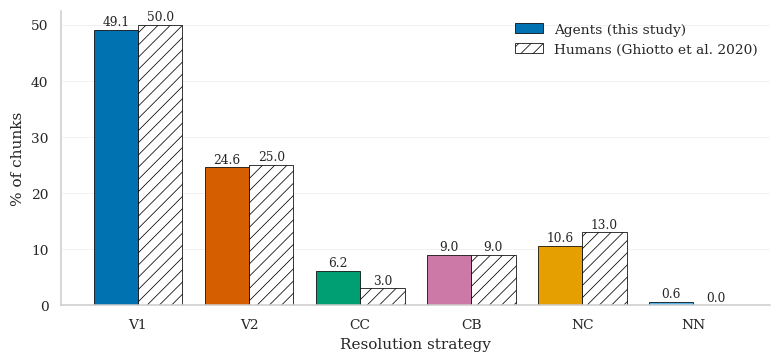

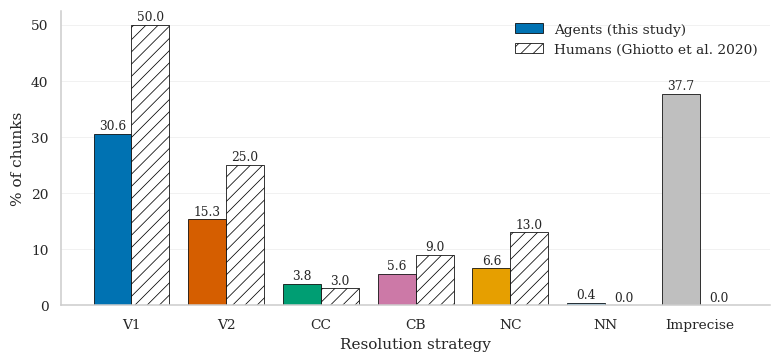

In [8]:
GHIOTTO_HUMAN = {
    "V1": 50,
    "V2": 25,
    "CC": 3,
    "CB":  9,
    "NC": 13,
    "NN":  0,
    "Imprecise": 0.00,   # not reported in Ghiotto; kept as 0 for alignment
}

def _plot_vs_ghiotto(order, agent_dist_row, fname, annotate_imprecise=None):
    agent_pct = (agent_dist_row.reindex(order).fillna(0) * 100)
    human_pct = pd.Series({k: GHIOTTO_HUMAN[k] for k in order})
    x = np.arange(len(order))
    w = 0.4
    fig, ax = plt.subplots(figsize=(7.2, 3.4))
    # Agents: strategy colour fill, no hatch (luminance does the work)
    ax.bar(x - w/2, agent_pct.values, width=w,
           color=[STRATEGY_PALETTE[s] for s in order],
           edgecolor="black", linewidth=0.5, label="Agents (this study)")
    # Ghiotto reference: white fill + diagonal hatch (B&W-safe)
    ax.bar(x + w/2, human_pct.values, width=w,
           color="white", edgecolor="black", hatch="///",
           linewidth=0.5, label="Humans (Ghiotto et al. 2020)")
    ax.set_xticks(x)
    ax.set_xticklabels(order)
    ax.set_ylabel("% of chunks")
    ax.set_xlabel("Resolution strategy")
    ax.grid(axis="x", visible=False)
    ax.legend(loc="upper right", frameon=False)
    for i, v in enumerate(agent_pct.values):
        ax.text(x[i] - w/2, v + 0.8, f"{v:.1f}", ha="center", fontsize=8)
    for i, v in enumerate(human_pct.values):
        ax.text(x[i] + w/2, v + 0.8, f"{v:.1f}", ha="center", fontsize=8)
    if annotate_imprecise is not None:
        ax.text(0.99, 0.98,
                f"Imprecise chunks excluded: {annotate_imprecise:.1f}%",
                transform=ax.transAxes, ha="right", va="top", fontsize=8,
                color="dimgray")
    save_fig(fig, fname)
    plt.show()

if chunks.empty:
    print("No classified chunks yet -- run the pipeline first.")
else:
    # Paper variant: excluding Imprecise
    _plot_vs_ghiotto(
        STRATEGY_ORDER_EXCL,
        global_dist_excl.iloc[0],
        "rq2_global_vs_ghiotto_excl_imprecise",
        # annotate_imprecise=imp_pct_global,
    )
    # Full variant: including Imprecise (for reviewers / appendix)
    _plot_vs_ghiotto(
        STRATEGY_ORDER,
        global_dist_incl.iloc[0],
        "rq2_global_vs_ghiotto_incl_imprecise",
    )

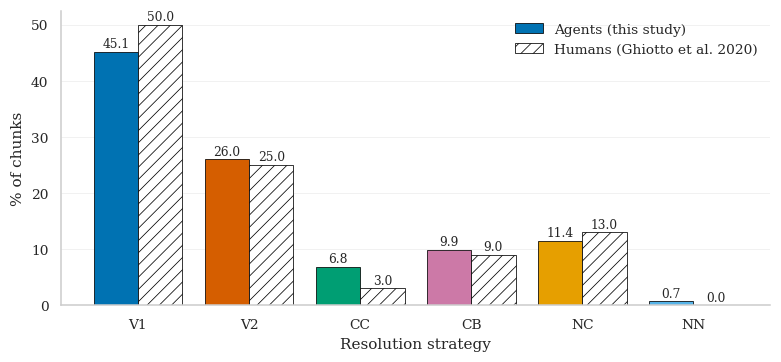

In [9]:
GHIOTTO_HUMAN = {
    "V1": 50,
    "V2": 25,
    "CC": 3,
    "CB":  9,
    "NC": 13,
    "NN":  0,
    "Imprecise": 0.00,   # not reported in Ghiotto; kept as 0 for alignment
}

def _plot_vs_ghiotto(order, agent_dist_row, fname, annotate_imprecise=None):
    agent_pct = (agent_dist_row.reindex(order).fillna(0) * 100)
    human_pct = pd.Series({k: GHIOTTO_HUMAN[k] for k in order})
    x = np.arange(len(order))
    w = 0.4
    fig, ax = plt.subplots(figsize=(7.2, 3.4))
    # Agents: strategy colour fill, no hatch (luminance does the work)
    ax.bar(x - w/2, agent_pct.values, width=w,
           color=[STRATEGY_PALETTE[s] for s in order],
           edgecolor="black", linewidth=0.5, label="Agents (this study)")
    # Ghiotto reference: white fill + diagonal hatch (B&W-safe)
    ax.bar(x + w/2, human_pct.values, width=w,
           color="white", edgecolor="black", hatch="///",
           linewidth=0.5, label="Humans (Ghiotto et al. 2020)")
    ax.set_xticks(x)
    ax.set_xticklabels(order)
    ax.set_ylabel("% of chunks")
    ax.set_xlabel("Resolution strategy")
    ax.grid(axis="x", visible=False)
    ax.legend(loc="upper right", frameon=False)
    for i, v in enumerate(agent_pct.values):
        ax.text(x[i] - w/2, v + 0.8, f"{v:.1f}", ha="center", fontsize=8)
    for i, v in enumerate(human_pct.values):
        ax.text(x[i] + w/2, v + 0.8, f"{v:.1f}", ha="center", fontsize=8)
    if annotate_imprecise is not None:
        ax.text(0.99, 0.98,
                f"Imprecise chunks excluded: {annotate_imprecise:.1f}%",
                transform=ax.transAxes, ha="right", va="top", fontsize=8,
                color="dimgray")
    save_fig(fig, fname)
    plt.show()

if chunks.empty:
    print("No classified chunks yet -- run the pipeline first.")
else:
    # Paper variant: human resolvers excluding Imprecise
    _plot_vs_ghiotto(
        STRATEGY_ORDER_EXCL,
        human_dist_excl.iloc[0],
        "rq2_human_vs_ghiotto_excl_imprecise",
    )

In [10]:
global_dist_excl

strategy,V1,V2,CC,CB,NC,NN
all,0.491248,0.245776,0.061754,0.089727,0.105529,0.005967


## 4. Figure 2 — Strategy distribution by agent (vertical stacked bars)

Each column is an agent; segment colours + hatches are the canonical
strategies. The paper figure excludes `Imprecise`; the per-agent
Imprecise share is printed below as a small table so it can still be
discussed in the text.

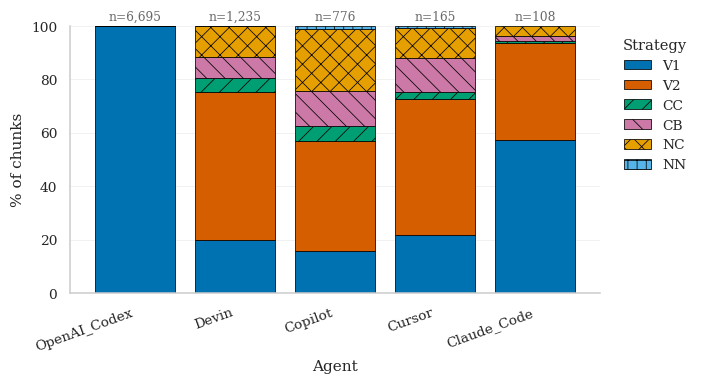

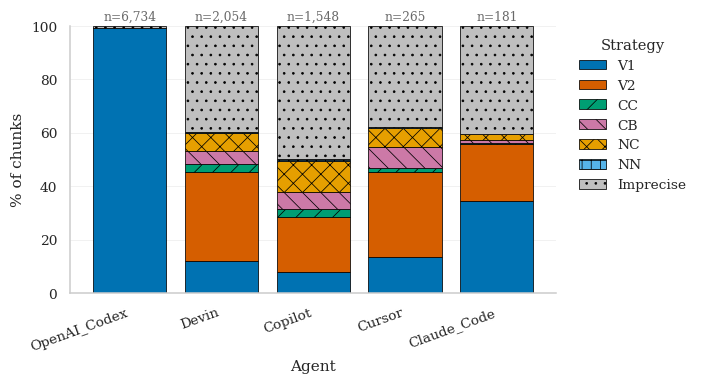

Chunks per agent:
agent
OpenAI_Codex    94150
Copilot         15308
Devin            6350
Cursor           3638
Claude_Code      2153

Imprecise share per agent (%):
agent
OpenAI_Codex    41.05
Cursor          36.94
Claude_Code     29.59
Devin           24.82
Copilot         23.80


In [11]:
if not chunks.empty and "agent" in chunks.columns:
    # Paper view (excluding Imprecise)
    agent_resolved = chunks[chunks['resolver_type']=='agent']
    by_agent_excl = strategy_frame_for_plot(agent_resolved, "agent", exclude_imprecise=True, exclude_unknown=False)
    ax = plot_strategy_stacked(by_agent_excl, STRATEGY_ORDER_EXCL,
                               orientation="vertical")
    ax.set_xlabel("Agent")
    save_fig(ax.figure, "rq2_by_agent_excl_imprecise")
    plt.show()

    # Full view (including Imprecise)
    by_agent_incl = strategy_frame_for_plot(agent_resolved, "agent", exclude_imprecise=False, exclude_unknown=False)
    ax = plot_strategy_stacked(by_agent_incl, STRATEGY_ORDER,
                               orientation="vertical")
    ax.set_xlabel("Agent")
    save_fig(ax.figure, "rq2_by_agent_incl_imprecise")
    plt.show()

    print("Chunks per agent:")
    print(chunks["agent"].value_counts().to_string())
    print("\nImprecise share per agent (%):")
    print((imprecise_share(chunks, group_col="agent") * 100).round(2).sort_values(ascending=False).to_string())

## 5. Figure 3 — Strategy distribution by language (top-N)

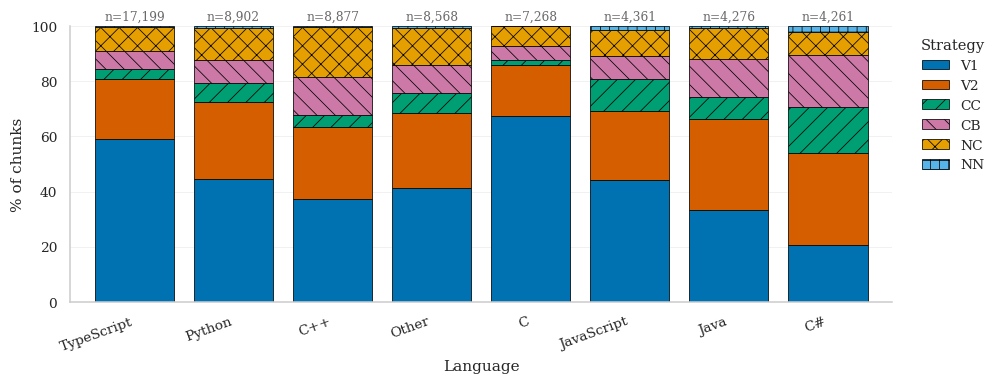

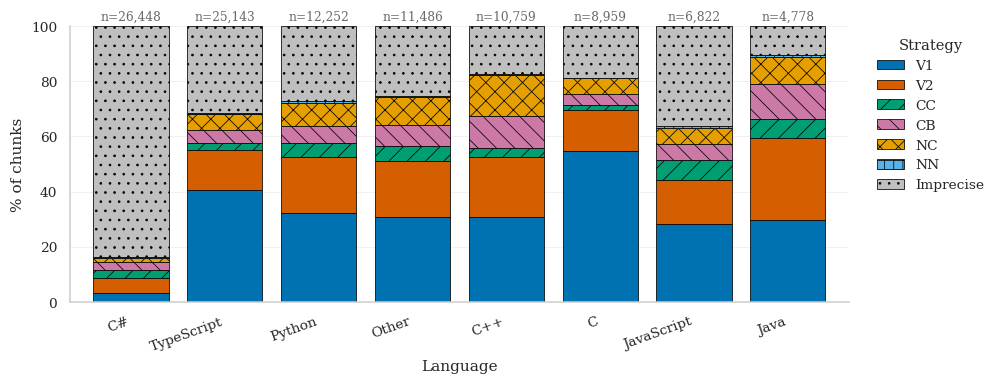


Imprecise share per language (%):
language_top
C#            83.89
JavaScript    36.07
TypeScript    31.60
Python        27.34
Other         25.40
Unknown       19.48
C             18.87
C++           17.49
Java          10.51


In [12]:
if not chunks.empty and "language_top" in chunks.columns:
    by_lang_excl = strategy_frame_for_plot(chunks, "language_top", exclude_imprecise=True)
    ax = plot_strategy_stacked(by_lang_excl, STRATEGY_ORDER_EXCL,
                               orientation="vertical")
    ax.set_xlabel("Language")
    save_fig(ax.figure, "rq2_by_language_excl_imprecise")
    plt.show()

    by_lang_incl = strategy_frame_for_plot(chunks, "language_top", exclude_imprecise=False)
    ax = plot_strategy_stacked(by_lang_incl, STRATEGY_ORDER,
                               orientation="vertical")
    ax.set_xlabel("Language")
    save_fig(ax.figure, "rq2_by_language_incl_imprecise")
    plt.show()

    print("\nImprecise share per language (%):")
    print((imprecise_share(chunks, group_col="language_top") * 100).round(2).sort_values(ascending=False).to_string())

## 6. Figure 4 — Strategy distribution by PR task type

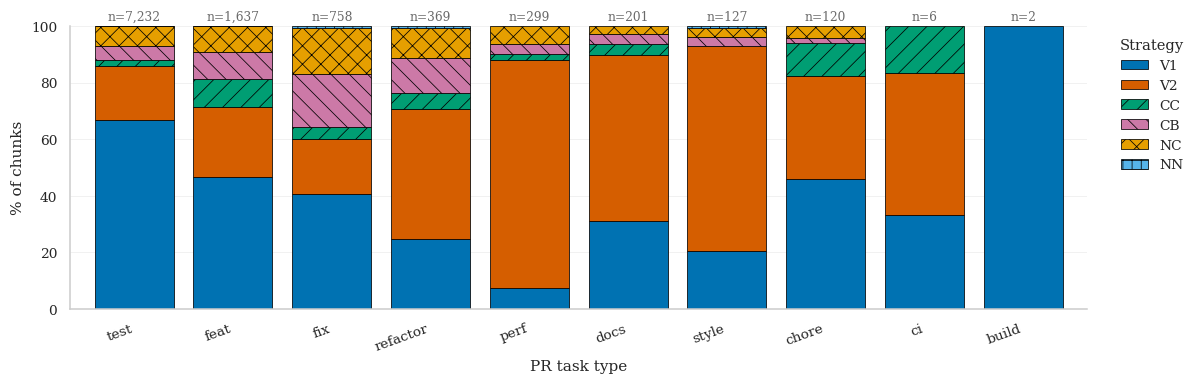

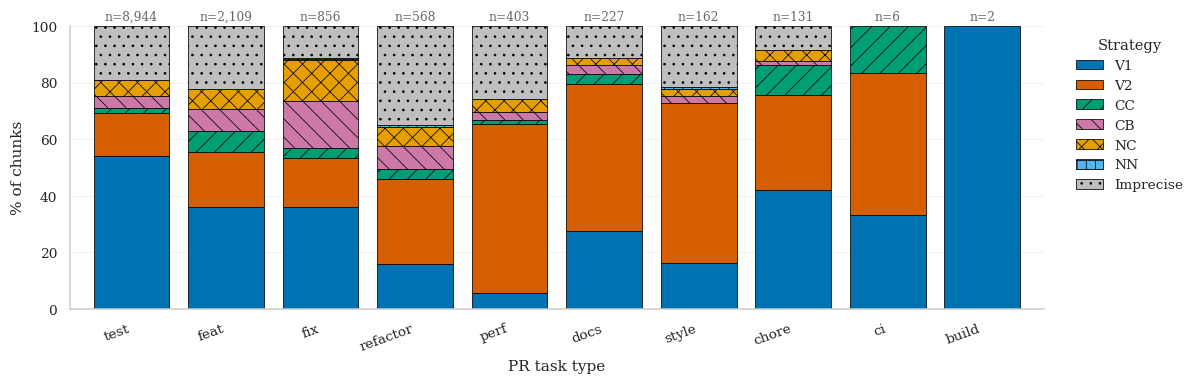


Imprecise share per PR task type (%):
pr_task_type
refactor    35.04
perf        25.81
feat        22.38
style       21.60
test        19.14
fix         11.44
docs        11.26
chore        8.40
build        0.00
ci           0.00


In [13]:
if not chunks.empty and "pr_task_type" in chunks.columns:
    subset = chunks.dropna(subset=["pr_task_type"]).copy()
    if subset.empty:
        print("pr_task_type is only populated under --pop-only.")
    else:
        by_task_excl = strategy_frame_for_plot(subset, "pr_task_type", exclude_imprecise=True)
        ax = plot_strategy_stacked(by_task_excl, STRATEGY_ORDER_EXCL,
                                   orientation="vertical")
        ax.set_xlabel("PR task type")
        save_fig(ax.figure, "rq2_by_task_type_excl_imprecise")
        plt.show()

        by_task_incl = strategy_frame_for_plot(subset, "pr_task_type", exclude_imprecise=False)
        ax = plot_strategy_stacked(by_task_incl, STRATEGY_ORDER,
                                   orientation="vertical")
        ax.set_xlabel("PR task type")
        save_fig(ax.figure, "rq2_by_task_type_incl_imprecise")
        plt.show()

        print("\nImprecise share per PR task type (%):")
        print((imprecise_share(subset, group_col="pr_task_type") * 100).round(2).sort_values(ascending=False).to_string())

## 7. Figure 5 — Ghiotto-Figure-16-style horizontal breakdown

Ghiotto et al.\ (TSE 2020) report the strategy distribution in a
**horizontal 100%-stacked** layout, one bar per slice, with the
strategy segments ordered consistently and annotated with the sample
size. This view is better than grouped vertical bars when the slices
have long labels (languages, PR task types) and when the reader needs
to scan shares across rows at a glance.

We replicate that layout for the four cross-cutting axes of this
study — agent, resolver, language (top-N), and PR task type — in a
single composite figure. The paper variant excludes `Imprecise`; the
audit variant (with `Imprecise` kept as its own segment) is saved
next to it. The panels share the same legend, colour map, and hatch
map, so the figure reads as a single coordinated view.

/home/heleno/agentic-conflicts/analysis/common.py:712: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


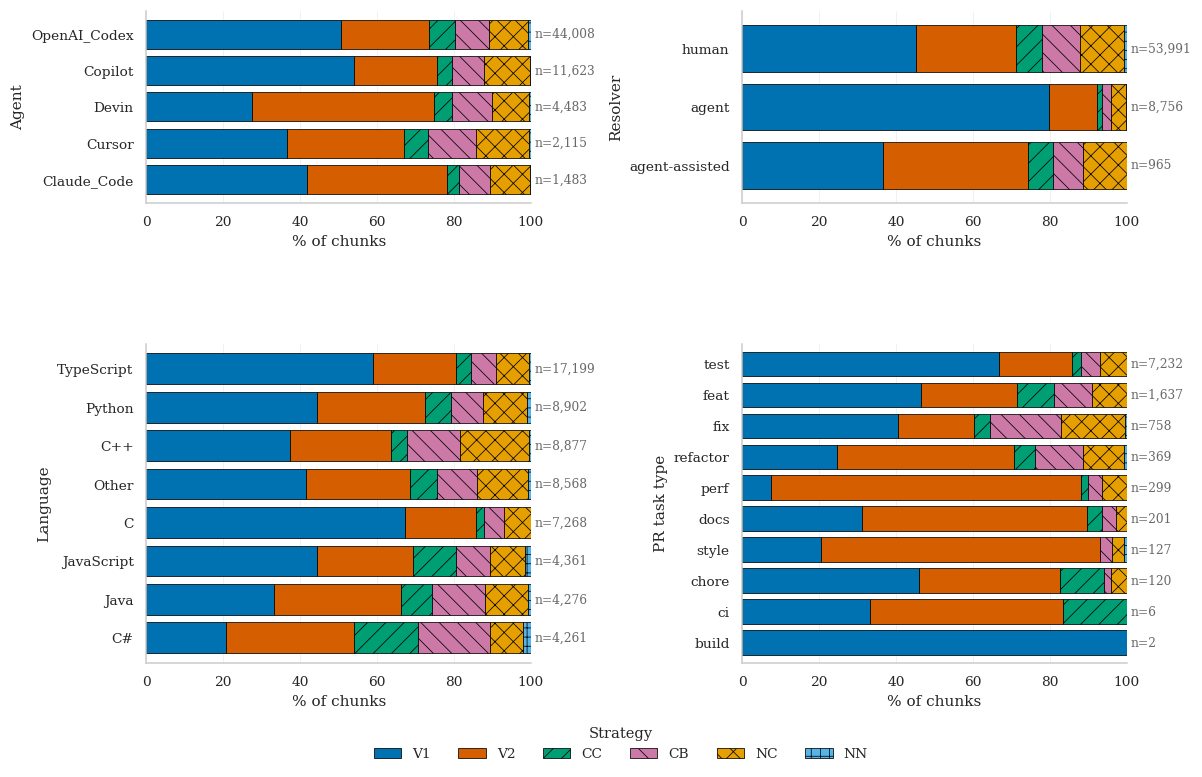

/home/heleno/agentic-conflicts/analysis/common.py:712: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


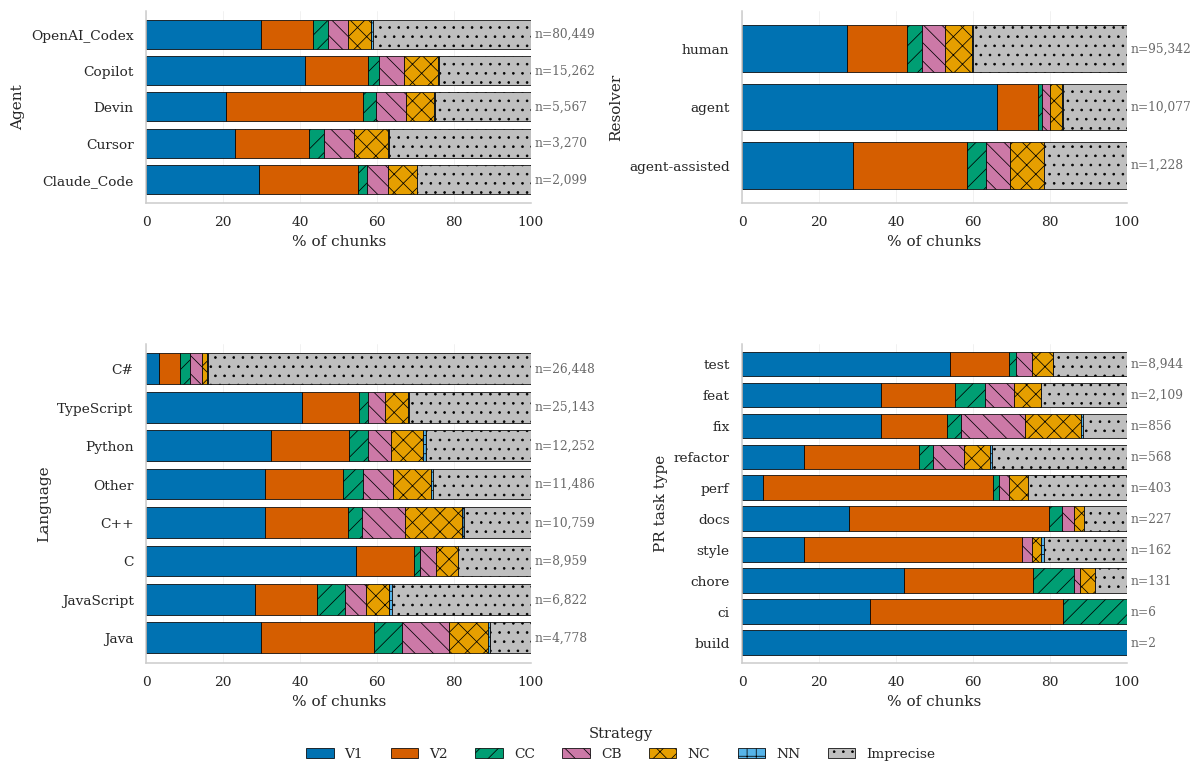

In [14]:
def _composite_fig16(exclude_imprecise: bool):
    """Four-panel horizontal stacked-bar composite (Ghiotto Fig. 16 style).

    Panels:
      (a) by agent              (top-left)
      (b) by resolver type      (top-right)
      (c) by language (top-N)   (bottom-left)
      (d) by PR task type       (bottom-right, AIDev-pop only)
    """
    order = STRATEGY_ORDER_EXCL if exclude_imprecise else STRATEGY_ORDER

    # Build each frame -- drop any axis whose column is absent from the
    # chunk frame (``resolver_type`` and ``pr_task_type`` may be missing
    # under certain pipeline tiers).
    panels = []
    if "agent" in chunks.columns:
        panels.append(("Agent",
                       strategy_frame_for_plot(chunks, "agent",
                                               exclude_imprecise=exclude_imprecise)))
    if "resolver_type" in chunks.columns:
        sub = chunks[chunks["resolver_type"].isin(["agent", "human", "agent-assisted"])]
        if not sub.empty:
            panels.append(("Resolver",
                           strategy_frame_for_plot(sub, "resolver_type",
                                                   exclude_imprecise=exclude_imprecise)))
    if "language_top" in chunks.columns:
        panels.append(("Language",
                       strategy_frame_for_plot(chunks, "language_top",
                                               exclude_imprecise=exclude_imprecise)))
    if "pr_task_type" in chunks.columns:
        task_sub = chunks.dropna(subset=["pr_task_type"])
        if not task_sub.empty:
            panels.append(("PR task type",
                           strategy_frame_for_plot(task_sub, "pr_task_type",
                                                   exclude_imprecise=exclude_imprecise)))

    n = len(panels)
    if n == 0:
        print("No stratifications available; skipping composite figure.")
        return

    # Two-column grid that holds up to 4 panels. Row heights grow with
    # the number of rows in each frame so no label overlaps.
    ncols = 2 if n >= 2 else 1
    nrows = (n + ncols - 1) // ncols
    heights = []
    for i in range(nrows):
        row_panels = panels[i * ncols : (i + 1) * ncols]
        max_rows = max(len(df) for _, df in row_panels)
        heights.append(max(2.2, 0.38 * max_rows + 1.0))
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(11.5, sum(heights)),
        gridspec_kw={"height_ratios": heights, "wspace": 0.55, "hspace": 0.55},
        squeeze=False,
    )

    for idx, (label, df) in enumerate(panels):
        r, c = divmod(idx, ncols)
        ax = axes[r, c]
        plot_strategy_stacked(
            df, order=order, orientation="horizontal", ax=ax,
            annotate_n=True, legend=False,
        )
        ax.set_xlabel("% of chunks")
        ax.set_ylabel(label, fontsize=10)

    # Hide any unused subplot cells so the figure stays clean.
    for idx in range(n, nrows * ncols):
        r, c = divmod(idx, ncols)
        axes[r, c].set_visible(False)

    # Single shared legend at the bottom of the figure.
    handles = [
        plt.Rectangle((0, 0), 1, 1,
                      facecolor=STRATEGY_PALETTE[s],
                      hatch=STRATEGY_HATCH.get(s, ""),
                      edgecolor="black", linewidth=0.5)
        for s in order
    ]
    fig.legend(
        handles, order,
        title="Strategy",
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=len(order), frameon=False,
    )

    suffix = "excl_imprecise" if exclude_imprecise else "incl_imprecise"
    save_fig(fig, f"rq2_fig16_composite_{suffix}")
    plt.show()


if not chunks.empty:
    # Paper variant
    _composite_fig16(exclude_imprecise=True)
    # Audit variant
    _composite_fig16(exclude_imprecise=False)

### 7a. Single-axis horizontal breakdowns

Individual Ghiotto-Fig.-16-style figures per stratum, saved as
stand-alone PDFs so the paper can include them independently of the
composite. Same palette, same hatches, same ordering as the
composite.

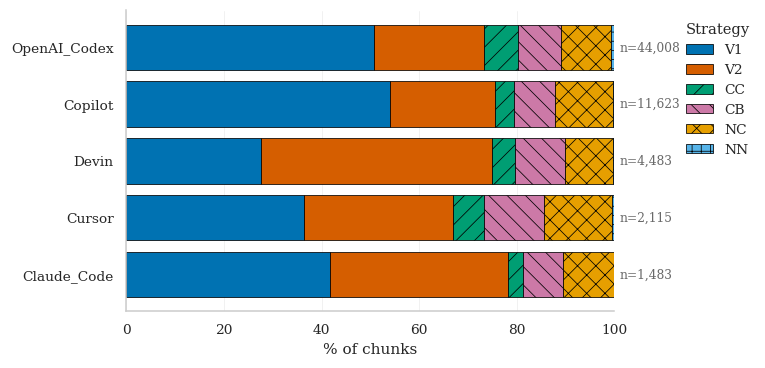

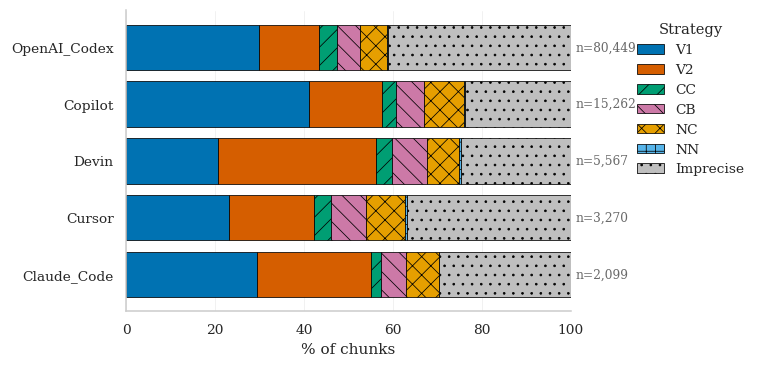

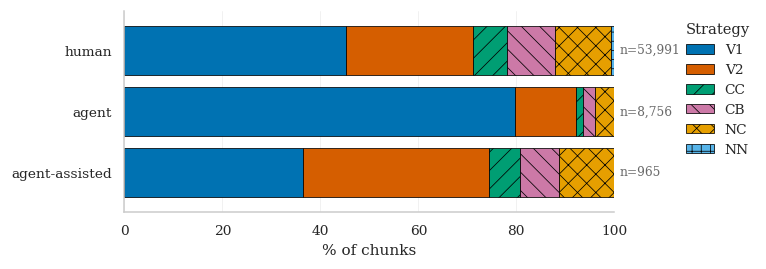

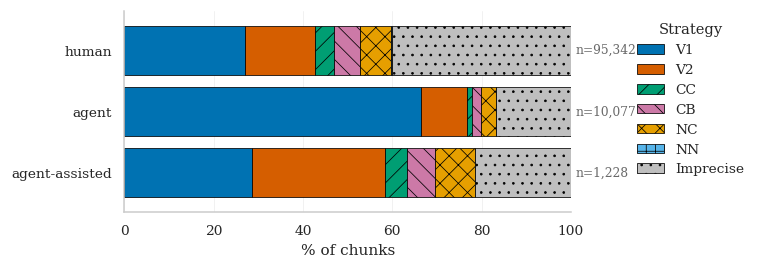

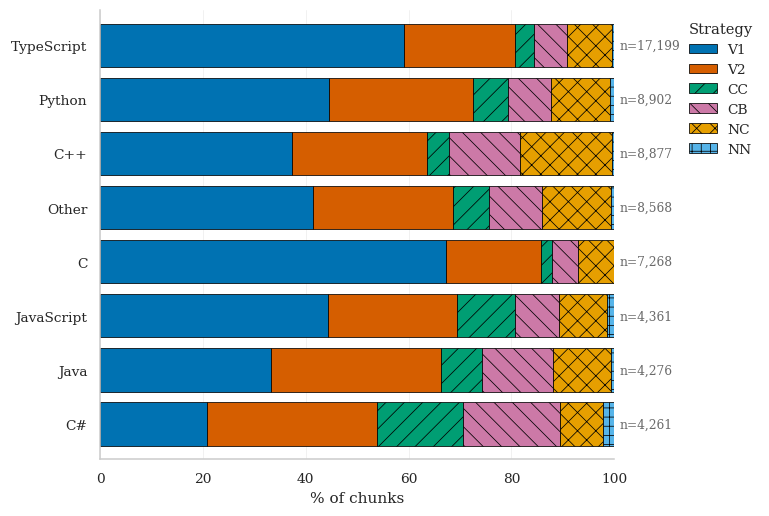

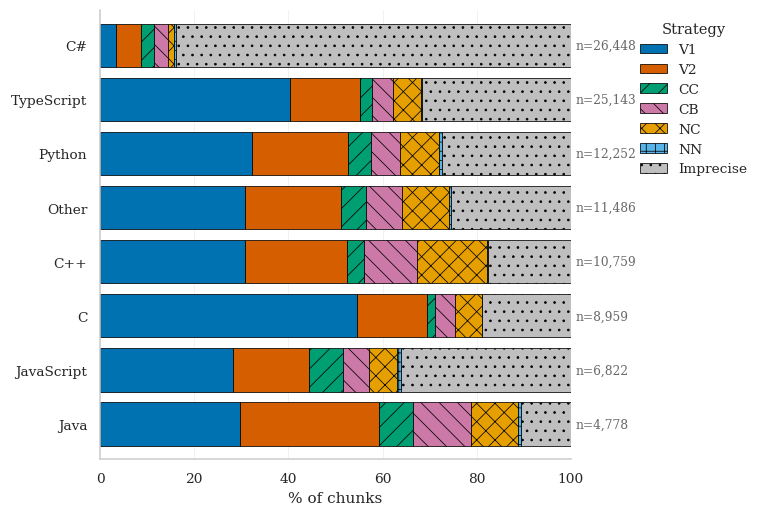

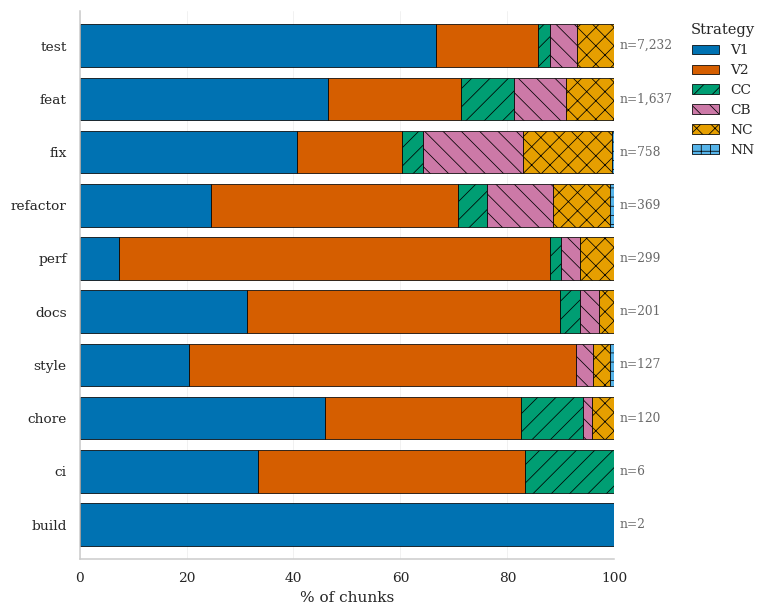

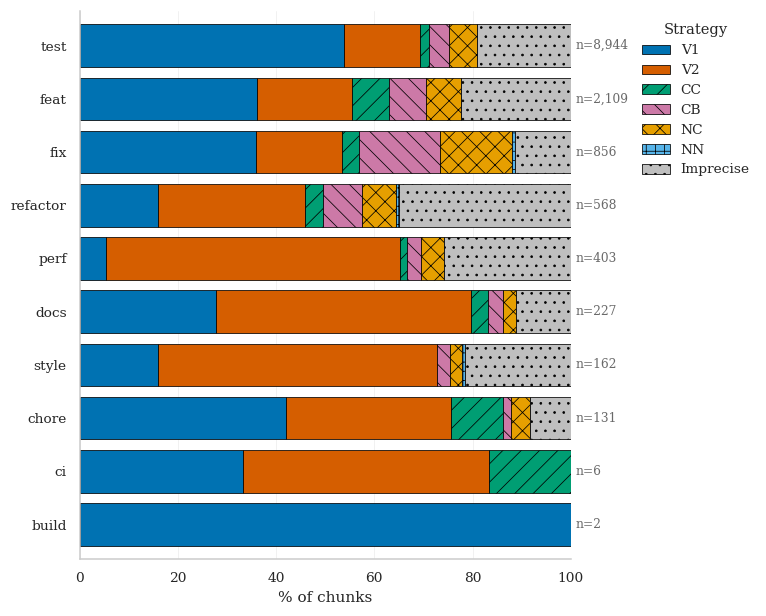

In [15]:
def _single_fig16(df, fname, exclude_imprecise=True):
    order = STRATEGY_ORDER_EXCL if exclude_imprecise else STRATEGY_ORDER
    ax = plot_strategy_stacked(df, order=order, orientation="horizontal",
                               annotate_n=True, legend=True)
    save_fig(ax.figure, fname)
    plt.show()


if not chunks.empty:
    if "agent" in chunks.columns:
        _single_fig16(
            strategy_frame_for_plot(chunks, "agent", exclude_imprecise=True),
            "rq2_fig16_by_agent_excl_imprecise", exclude_imprecise=True,
        )
        _single_fig16(
            strategy_frame_for_plot(chunks, "agent", exclude_imprecise=False),
            "rq2_fig16_by_agent_incl_imprecise", exclude_imprecise=False,
        )

    if "resolver_type" in chunks.columns:
        sub = chunks[chunks["resolver_type"].isin(["agent", "human", "agent-assisted"])]
        if not sub.empty:
            _single_fig16(
                strategy_frame_for_plot(sub, "resolver_type", exclude_imprecise=True),
                "rq2_fig16_by_resolver_excl_imprecise", exclude_imprecise=True,
            )
            _single_fig16(
                strategy_frame_for_plot(sub, "resolver_type", exclude_imprecise=False),
                "rq2_fig16_by_resolver_incl_imprecise", exclude_imprecise=False,
            )

    if "language_top" in chunks.columns:
        _single_fig16(
            strategy_frame_for_plot(chunks, "language_top", exclude_imprecise=True),
            "rq2_fig16_by_language_excl_imprecise", exclude_imprecise=True,
        )
        _single_fig16(
            strategy_frame_for_plot(chunks, "language_top", exclude_imprecise=False),
            "rq2_fig16_by_language_incl_imprecise", exclude_imprecise=False,
        )

    if "pr_task_type" in chunks.columns:
        task_sub = chunks.dropna(subset=["pr_task_type"])
        if not task_sub.empty:
            _single_fig16(
                strategy_frame_for_plot(task_sub, "pr_task_type", exclude_imprecise=True),
                "rq2_fig16_by_task_type_excl_imprecise", exclude_imprecise=True,
            )
            _single_fig16(
                strategy_frame_for_plot(task_sub, "pr_task_type", exclude_imprecise=False),
                "rq2_fig16_by_task_type_incl_imprecise", exclude_imprecise=False,
            )

## 8. Per-stratum numerical tables

In [16]:
if not chunks.empty:
    for axis in ("agent", "language_top", "pr_task_type", "resolver_type"):
        if axis not in chunks.columns:
            continue
        # Paper view
        tbl_excl = strategy_distribution(chunks, group_col=axis, exclude_imprecise=True) * 100
        tbl_excl["n_classifiable"] = chunks[chunks["strategy"] != "Imprecise"].groupby(axis).size()
        tbl_excl["imprecise_pct"] = (imprecise_share(chunks, group_col=axis) * 100).round(2)
        tbl_excl["n_total"] = chunks.groupby(axis).size()
        tbl_excl = tbl_excl.sort_values("n_total", ascending=False).round(2)
        print(f"\n=== Strategy % by {axis} (Imprecise excluded) ===")
        print(tbl_excl.to_string())

        # Full view
        tbl_incl = strategy_distribution(chunks, group_col=axis) * 100
        tbl_incl["n"] = chunks.groupby(axis).size()
        tbl_incl = tbl_incl.sort_values("n", ascending=False).round(2)
        print(f"\n=== Strategy % by {axis} (Imprecise included) ===")
        print(tbl_incl.to_string())


=== Strategy % by agent (Imprecise excluded) ===
strategy         V1     V2    CC     CB     NC    NN  n_classifiable  imprecise_pct  n_total
agent                                                                                       
OpenAI_Codex  50.66  22.71  6.85   8.88  10.20  0.69           55503          41.05    94150
Copilot       54.08  21.46  3.94   8.29  11.92  0.31           11665          23.80    15308
Devin         27.57  47.28  4.75  10.28   9.74  0.38            4774          24.82     6350
Cursor        36.49  30.47  6.23  12.47  13.86  0.48            2294          36.94     3638
Claude_Code   41.69  36.54  3.10   8.05  10.49  0.13            1516          29.59     2153

=== Strategy % by agent (Imprecise included) ===
strategy         V1     V2    CC    CB    NC    NN  Imprecise      n
agent                                                               
OpenAI_Codex  29.87  13.39  4.04  5.24  6.01  0.41      41.05  94150
Copilot       41.21  16.35  3.00  6.32  9.

## 9. Figure 6 — Size distributions: chunks per merge and LoC per chunk

Two-panel figure:

* **Left** — boxplot of the number of conflicting chunks per merge
  (restricted to merges with at least one conflict). Y-axis on log
  scale because the distribution is heavily right-skewed.
* **Right** — side-by-side boxplots of three chunk-size metrics:
  lines of code in V1, lines of code in V2, and lines of code in the
  resolution. Y-axis on log scale for the same reason.

Both panels use the paper's serif / whitegrid aesthetic and are saved
as `rq2_size_distributions` (PDF + PNG).

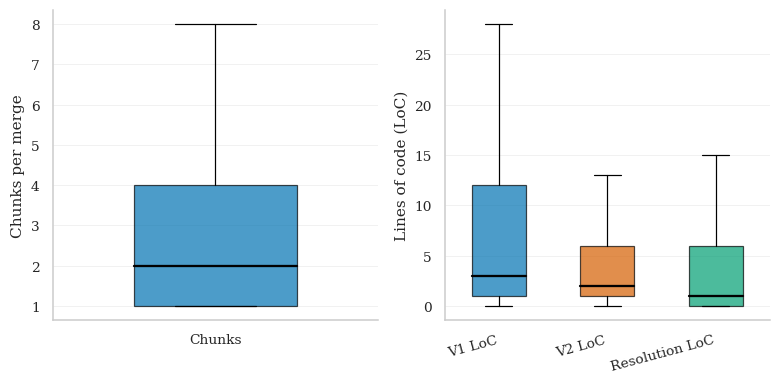

In [17]:
if not chunks.empty:
    merges = build_merge_frame(tables)
    conflict_merges = merges[merges["n_chunks"] > 0]

    # ── colour palette (Okabe-Ito, same as strategy colours) ──────────────
    _BLUE       = "#0072B2"
    _VERMILLION = "#D55E00"
    _GREEN      = "#009E73"

    # ── LOC data ───────────────────────────────────────────────────────────
    loc_cfg = [
        ("v1_loc",         "V1 LoC",         _BLUE),
        ("v2_loc",         "V2 LoC",         _VERMILLION),
        ("resolution_loc", "Resolution LoC", _GREEN),
    ]
    loc_series = []
    loc_labels = []
    loc_colors = []
    for col, label, color in loc_cfg:
        if col in chunks.columns:
            vals = chunks[col].dropna()
            # vals = vals[vals > 0]          # drop zeros for log scale
            if not vals.empty:
                loc_series.append(vals.values)
                loc_labels.append(label)
                loc_colors.append(color)

    # ── figure ─────────────────────────────────────────────────────────────
    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(7.2, 3.6))

    # Left — chunks per merge
    bp_l = ax_l.boxplot(
        conflict_merges["n_chunks"].values,
        patch_artist=True,
        showfliers=False,
        widths=0.5,
        medianprops=dict(color="black", linewidth=1.5),
        whiskerprops=dict(linewidth=0.8),
        capprops=dict(linewidth=0.8),
        flierprops=dict(marker=".", markersize=3, alpha=0.4,
                        markerfacecolor=_BLUE, markeredgecolor=_BLUE),
    )
    bp_l["boxes"][0].set_facecolor(_BLUE)
    bp_l["boxes"][0].set_alpha(0.7)
    bp_l["boxes"][0].set_edgecolor("black")
    bp_l["boxes"][0].set_linewidth(0.8)
    # ax_l.set_yscale("log")
    ax_l.set_xticks([1])
    ax_l.set_xticklabels(["Chunks"])
    ax_l.set_ylabel("Chunks per merge")
    ax_l.grid(axis="x", visible=False)

    # Right — LoC distributions
    if loc_series:
        bp_r = ax_r.boxplot(
            loc_series,
            patch_artist=True,
            showfliers=False,
            widths=0.5,
            medianprops=dict(color="black", linewidth=1.5),
            whiskerprops=dict(linewidth=0.8),
            capprops=dict(linewidth=0.8),
            flierprops=dict(marker=".", markersize=3, alpha=0.4),
        )
        for patch, color in zip(bp_r["boxes"], loc_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
            patch.set_edgecolor("black")
            patch.set_linewidth(0.8)
        for fliers, color in zip(bp_r["fliers"], loc_colors):
            fliers.set_markerfacecolor(color)
            fliers.set_markeredgecolor(color)
        # ax_r.set_yscale("log")
        ax_r.set_xticks(range(1, len(loc_labels) + 1))
        ax_r.set_xticklabels(loc_labels, rotation=15, ha="right")
        ax_r.set_ylabel("Lines of code (LoC)")
        ax_r.grid(axis="x", visible=False)
    else:
        ax_r.text(0.5, 0.5, "LoC columns not available",
                  transform=ax_r.transAxes, ha="center", va="center",
                  color="dimgray", fontsize=9)

    save_fig(fig, "rq2_size_distributions")
    plt.show()

In [18]:
merges[merges['resolver_type']=='agent']

,pr_id,merge_sha,parent1_sha,parent2_sha,author,committer,repo_full_name,resolver_type,n_chunks,has_conflict,full_name,agent,language,pr_task_type,state,merged_at,language_top
1,3.275372e+09,7d68daaa16a664eeff559fdb8cb825a75d60dcc4,d2f315b028dbe05f988a8c9dc90bf4df08cbe7b4,e22f7f24fa7742da460d9019d47515ee9d2b0423,copilot-swe-agent[bot],copilot-swe-agent[bot],07JP27/DeepResearch-dotnet,agent,2,True,07JP27/DeepResearch-dotnet,Copilot,C#,None,open,None,C#
54,3.147206e+09,30972f06efc7de72d70917c389364db4f7baa314,f7a2150034dd867c4a0d98c4fe47942343b26057,926dec643b8b4dbfe3628678153c3b261a2851a0,copilot-swe-agent[bot],copilot-swe-agent[bot],75py/habit-tracker,agent,0,False,75py/habit-tracker,Copilot,Kotlin,None,closed,None,Other
55,3.153438e+09,8c025619c2b844cd11ee1b96cb47141d8b8bfb95,92d9271d66d0ccade2836d355ba03851ee1323a2,c2300f322486a9122a567f18abde6633789346e0,copilot-swe-agent[bot],copilot-swe-agent[bot],75py/habit-tracker,agent,4,True,75py/habit-tracker,Copilot,Kotlin,None,open,None,Other
56,3.167946e+09,a7439022cd6543980575a0f4d221c09976d1aec8,19de4dc4631910e585d40f5b003b84da950eabaf,259287205b1b2f99f3a6981b6f62d961122bd436,copilot-swe-agent[bot],copilot-swe-agent[bot],75py/habit-tracker,agent,0,False,75py/habit-tracker,Copilot,Kotlin,None,open,None,Other
77,2.806857e+09,e091b744fa951f1a6f538833920ea6b55d256330,b395bedc7e124bf7fcf93fddd773e770204937e8,76285faaf2eec5dec768397e20989c633ad447b8,Devin AI,Devin AI,AInoob/WhatLLMCanDo,agent,6,True,AInoob/WhatLLMCanDo,Devin,TypeScript,None,closed,None,TypeScript
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50497,3.164144e+09,9452423f8a94d59be2c4420df02afe15c0bc1b13,609bb3fd10cf24a12185ef8ddb9432f4018c55f8,97e6f7980aca97cfc30161abb22090fd8ec383b1,Devin AI,Devin AI,yossi64/page,agent,0,False,yossi64/page,Devin,None,None,closed,None,Unknown
50510,3.020130e+09,2400acb5c108f6cc1201ce318d4613040db81dbd,5e0597828a600c66aa22972028e62f56e3b95825,addcd7827253582385b08e048a21eb6ae4c24b73,Devin AI,Devin AI,yujiosaka/ChatIQ,agent,0,False,yujiosaka/ChatIQ,Devin,Python,None,closed,None,Python
50511,3.029727e+09,5fee3866a5626c719604dc7dd0bf2438de153965,380bb592f2f1fefd3eb40b74812ad31f14198076,62e1bde036318a1ee1c02d4eee94b10c9f50f72e,Devin AI,Devin AI,yuki-snow1823/for_devin,agent,0,False,yuki-snow1823/for_devin,Devin,HTML,None,closed,None,Other
50561,3.160658e+09,f04e955fc3a3ce3acc5230b14912b24b9d9f81d8,79aa4327a9b1075166a84ef24c2bb6be9b53cca6,1ff0a55e18a5dbc6f622fa7b37f54d77e473ac3e,Zachary J. Fields (Copilot),GitHub,zakoverflow/notecard-schema,agent,0,False,zakoverflow/notecard-schema,Copilot,Python,None,closed,2025-06-19T15:09:16Z,Python


In [19]:
merges[merges['merge_sha'].isin(list(chunks[(chunks['resolver_type']=='agent') & (chunks['strategy']!='Imprecise') ]['merge_sha']))].groupby('agent').count()

,pr_id,merge_sha,parent1_sha,parent2_sha,author,committer,repo_full_name,resolver_type,n_chunks,has_conflict,full_name,language,pr_task_type,state,merged_at,language_top
agent,,,,,,,,,,,,,,,,
Claude_Code,11,11,11,11,11,11,11,11,11,11,11,11,0,11,9,11
Copilot,116,116,116,116,116,116,116,116,116,116,116,115,21,116,56,116
Cursor,34,34,34,34,34,34,34,34,34,34,34,34,1,34,21,34
Devin,214,214,214,214,214,214,214,214,214,214,214,210,24,214,93,214
OpenAI_Codex,61,61,61,61,61,61,61,61,61,61,61,61,0,61,57,61


In [20]:
merges[merges['merge_sha'].isin(list(chunks[(chunks['resolver_type']=='human') & (chunks['strategy']!='Imprecise') ]['merge_sha']))].groupby('agent').count()

,pr_id,merge_sha,parent1_sha,parent2_sha,author,committer,repo_full_name,resolver_type,n_chunks,has_conflict,full_name,language,pr_task_type,state,merged_at,language_top
agent,,,,,,,,,,,,,,,,
Claude_Code,151,151,151,151,151,151,151,151,151,151,151,145,34,151,109,151
Copilot,1634,1634,1634,1634,1634,1634,1634,1634,1634,1634,1634,1617,988,1634,1225,1634
Cursor,418,418,418,418,418,418,418,418,418,418,418,401,123,418,279,418
Devin,526,526,526,526,526,526,526,526,526,526,526,500,144,526,167,526
OpenAI_Codex,11034,11034,11034,11034,11034,11034,11034,11034,11034,11034,11034,9265,313,11034,7259,11034


In [21]:
merges[merges['merge_sha'].isin(list(chunks[(chunks['resolver_type']=='agent-assisted') & (chunks['strategy']!='Imprecise') ]['merge_sha']))].groupby('agent').count()

,pr_id,merge_sha,parent1_sha,parent2_sha,author,committer,repo_full_name,resolver_type,n_chunks,has_conflict,full_name,language,pr_task_type,state,merged_at,language_top
agent,,,,,,,,,,,,,,,,
Claude_Code,51,51,51,51,51,51,51,51,51,51,51,51,8,51,31,51
Copilot,3,3,3,3,3,3,3,3,3,3,3,3,1,3,0,3
Cursor,4,4,4,4,4,4,4,4,4,4,4,3,2,4,0,4
Devin,2,2,2,2,2,2,2,2,2,2,2,1,1,2,0,2
OpenAI_Codex,54,54,54,54,54,54,54,54,54,54,54,54,0,54,9,54


In [22]:
chunks[(chunks['resolver_type']=='agent') & (chunks['strategy']!='Imprecise') ]

,repo_full_name,pr_id,merge_sha,file_path,chunk_index,v1,base,v2,v1_loc,v2_loc,base_loc,resolution,localized_ok,resolution_loc,strategy,strategy_raw,resolver_type,full_name,agent,language,pr_task_type,state,merged_at,language_top
7,07JP27/DeepResearch-dotnet,3.275372e+09,7d68daaa16a664eeff559fdb8cb825a75d60dcc4,README.md,0,// Create DeepResearchService with TimeProvide...,var service = new DeepResearchService(ChatClie...,var timeProvider = TimeProvider.System;\nvar s...,6,4,2,var timeProvider = TimeProvider.System;\nvar s...,True,4,CB,Combination,agent,07JP27/DeepResearch-dotnet,Copilot,C#,None,open,None,C#
8,07JP27/DeepResearch-dotnet,3.275372e+09,7d68daaa16a664eeff559fdb8cb825a75d60dcc4,README_ja.md,0,// TimeProviderを使用してDeepResearchServiceを作成\nva...,var service = new DeepResearchService(ChatClie...,var timeProvider = TimeProvider.System;\nvar s...,6,4,2,var timeProvider = TimeProvider.System;\nvar s...,True,4,CB,Combination,agent,07JP27/DeepResearch-dotnet,Copilot,C#,None,open,None,C#
118,75py/habit-tracker,3.153438e+09,8c025619c2b844cd11ee1b96cb47141d8b8bfb95,composeApp/src/commonMain/kotlin/com/nagopy/km...,0,single { CompleteTaskFromNotificationUseCa...,single { CompleteTaskFromNotificationUseCa...,single { CompleteTaskFromNotificationUseCa...,2,1,2,single { CompleteTaskFromNotificationUseCa...,True,1,CB,Combination,agent,75py/habit-tracker,Copilot,Kotlin,None,open,None,Other
119,75py/habit-tracker,3.153438e+09,8c025619c2b844cd11ee1b96cb47141d8b8bfb95,composeApp/src/iosMain/kotlin/com/nagopy/kmp/h...,0,private val scheduleNextNotificationUseCas...,private val scheduleNextNotificationUseCas...,,1,0,1,private val scheduleNextNotificationUseCas...,True,1,V1,V1,agent,75py/habit-tracker,Copilot,Kotlin,None,open,None,Other
140,AInoob/WhatLLMCanDo,2.806857e+09,e091b744fa951f1a6f538833920ea6b55d256330,src/pages/index.tsx,0,import { observer } from 'mobx-react-lite'\nim...,import { observer } from 'mobx-react-lite'\nim...,import React from 'react';\nimport { observer ...,4,7,7,import { observer } from 'mobx-react-lite'\nim...,True,106,NC,New code,agent,AInoob/WhatLLMCanDo,Devin,TypeScript,None,closed,None,TypeScript
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121214,ymzkd/LaTeX-Matrix-Editor,3.195004e+09,1995a5439999d36d3d0befa7f1e1b102a42251c7,src/components/LaTeXMatrixEditor.tsx,5,"}, 0);\n } else {\n // 通常の更新\n ...","}, 0);","}, 50);\n } else {\n // 対称モードではな...",19,13,1,"}, 50);\n } else {\n // 通常の更新\n ...",True,30,CB,Combination,agent,ymzkd/LaTeX-Matrix-Editor,Devin,TypeScript,None,open,None,TypeScript
121215,ymzkd/LaTeX-Matrix-Editor,3.195004e+09,1995a5439999d36d3d0befa7f1e1b102a42251c7,src/index.css,0,},},}\n\n/* Preview area scroll styling */\n.bg-gr...,1,42,1,}\n\n/* Preview area scroll styling */\n.bg-gr...,True,42,V2,V2,agent,ymzkd/LaTeX-Matrix-Editor,Devin,TypeScript,None,open,None,TypeScript
121549,zuhairmahd/Autopilot,3.179809e+09,71238d5b7c499505955edcfb951d9390d79ed319,functions/GraphAPIFunctions.ps1,0,function DecodeJwtToken\n{\n [CmdletBinding...,function DecodeJwtToken\r\n{\r\n [CmdletBin...,function DecodeJwtToken\r\n{\r\n [CmdletBin...,2809,2393,2393,function DecodeJwtToken\n{\n [CmdletBinding...,True,2809,V1,V1,agent,zuhairmahd/Autopilot,Copilot,PowerShell,None,closed,2025-06-28T17:19:14Z,Other
121551,zuhairmahd/Autopilot,3.179809e+09,71238d5b7c499505955edcfb951d9390d79ed319,functions/MiscFunctions.ps1,0,function CreateSecretsFile()\n{\n [CmdletBi...,function CreateSecretsFile()\r\n{\r\n [Cmdl...,function CreateSecretsFile()\r\n{\r\n [Cmdl...,890,546,764,function CreateSecretsFile()\n{\n [CmdletBi...,True,890,V1,V1,agent,zuhairmahd/Autopilot,Copilot,PowerShell,None,closed,2025-06-28T17:19:14Z,Other


In [23]:
merges[merges['author'].str.contains('\[bot\]')]['author'].unique()

array(['copilot-swe-agent[bot]', 'nocobase[bot]', 'github-actions[bot]',
       'kodiakhq[bot]', 'bors[bot]', 'devin-ai-integration[bot]',
       'SF Machine User[bot]', 'air-hand-admin-app[bot]', 'mergify[bot]',
       'claude[bot]'], dtype=object)

In [24]:
merges[merges['merge_sha'].isin(list(chunks[(chunks['resolver_type']=='agent')]['merge_sha']))]['author'].unique()

array(['copilot-swe-agent[bot]', 'Devin AI', 'nocobase[bot]',
       'Cursor Agent', 'OpenAIRes', 'devin-ai-integration[bot]',
       'Claude Code Assistant', 'GitHub Copilot', 'devinkeehner',
       'Claude Code CC02', 'Claude Code-A', 'Claude Code CC01',
       'devintheamateurdevin', 'claude[bot]'], dtype=object)

In [25]:
chunks[(chunks['resolver_type']=='agent') & (chunks['strategy']!='Imprecise') & (chunks['merge_sha'].isin(list(merges[merges['agent']=='OpenAI_Codex']['merge_sha'])))]

,repo_full_name,pr_id,merge_sha,file_path,chunk_index,v1,base,v2,v1_loc,v2_loc,base_loc,resolution,localized_ok,resolution_loc,strategy,strategy_raw,resolver_type,full_name,agent,language,pr_task_type,state,merged_at,language_top
2059,BlazingSu/nocobase,3.186316e+09,19281cf797b6749a6648378dead9434c599785fc,lerna.json,0,"""version"": ""1.7.0-alpha.10"",","""version"": ""1.7.0-beta.16"",","""version"": ""1.7.0-beta.17"",",1,1,1,"""version"": ""1.7.0-alpha.10"",\n",True,1,V1,V1,agent,BlazingSu/nocobase,OpenAI_Codex,TypeScript,None,closed,2025-06-29T16:15:52Z,TypeScript
2060,BlazingSu/nocobase,3.186316e+09,19281cf797b6749a6648378dead9434c599785fc,packages/core/acl/package.json,0,"""version"": ""1.7.0-alpha.10"",","""version"": ""1.7.0-beta.16"",","""version"": ""1.7.0-beta.17"",",1,1,1,"""version"": ""1.7.0-alpha.10"",\n",True,1,V1,V1,agent,BlazingSu/nocobase,OpenAI_Codex,TypeScript,None,closed,2025-06-29T16:15:52Z,TypeScript
2061,BlazingSu/nocobase,3.186316e+09,19281cf797b6749a6648378dead9434c599785fc,packages/core/acl/package.json,1,"""@nocobase/resourcer"": ""1.7.0-alpha.10"",\n...","""@nocobase/resourcer"": ""1.7.0-beta.16"",\n ...","""@nocobase/resourcer"": ""1.7.0-beta.17"",\n ...",2,2,2,"""@nocobase/resourcer"": ""1.7.0-alpha.10"",\n...",True,2,V1,V1,agent,BlazingSu/nocobase,OpenAI_Codex,TypeScript,None,closed,2025-06-29T16:15:52Z,TypeScript
2062,BlazingSu/nocobase,3.186316e+09,19281cf797b6749a6648378dead9434c599785fc,packages/core/actions/package.json,0,"""version"": ""1.7.0-alpha.10"",","""version"": ""1.7.0-beta.16"",","""version"": ""1.7.0-beta.17"",",1,1,1,"""version"": ""1.7.0-alpha.10"",\n",True,1,V1,V1,agent,BlazingSu/nocobase,OpenAI_Codex,TypeScript,None,closed,2025-06-29T16:15:52Z,TypeScript
2063,BlazingSu/nocobase,3.186316e+09,19281cf797b6749a6648378dead9434c599785fc,packages/core/actions/package.json,1,"""@nocobase/cache"": ""1.7.0-alpha.10"",\n ...","""@nocobase/cache"": ""1.7.0-beta.16"",\n ""...","""@nocobase/cache"": ""1.7.0-beta.17"",\n ""...",3,3,3,"""@nocobase/cache"": ""1.7.0-alpha.10"",\n ...",True,3,V1,V1,agent,BlazingSu/nocobase,OpenAI_Codex,TypeScript,None,closed,2025-06-29T16:15:52Z,TypeScript
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110023,sankalp-thakur/proposalfrontend,3.076089e+09,9dddcd9ec44dcd8fe70995be1b45d3f2dfe94ac7,package-lock.json,39,"""node_modules/@reactflow/background"": {\n ...",,"""node_modules/@standard-schema/utils"": {\n...",102,6,0,"""node_modules/@standard-schema/utils"": {\n...",True,6,V2,V2,agent,sankalp-thakur/proposalfrontend,OpenAI_Codex,TypeScript,None,closed,None,TypeScript
110024,sankalp-thakur/proposalfrontend,3.076089e+09,9dddcd9ec44dcd8fe70995be1b45d3f2dfe94ac7,package-lock.json,40,"""node_modules/@types/d3-transition"": {\n ...",,"""node_modules/@types/file-saver"": {\n ...",31,6,0,"""node_modules/@types/file-saver"": {\n ...",True,6,V2,V2,agent,sankalp-thakur/proposalfrontend,OpenAI_Codex,TypeScript,None,closed,None,TypeScript
110025,sankalp-thakur/proposalfrontend,3.076089e+09,9dddcd9ec44dcd8fe70995be1b45d3f2dfe94ac7,package-lock.json,41,"""node_modules/detect-libc"": {\n ""vers...","""node_modules/detect-libc"": {\n ""vers...","""node_modules/dequal"": {\n ""version"":...",4,13,4,"""node_modules/dequal"": {\n ""version"":...",True,13,V2,V2,agent,sankalp-thakur/proposalfrontend,OpenAI_Codex,TypeScript,None,closed,None,TypeScript
110026,sankalp-thakur/proposalfrontend,3.076089e+09,9dddcd9ec44dcd8fe70995be1b45d3f2dfe94ac7,package-lock.json,42,"},\n ""node_modules/zustand"": {\n ""...",,"},\n ""node_modules/zod"": {\n ""vers...",28,9,0,"},\n ""node_modules/zod"": {\n ""vers...",True,9,V2,V2,agent,sankalp-thakur/proposalfrontend,OpenAI_Codex,TypeScript,None,closed,None,TypeScript


In [26]:
chunks[(chunks['resolver_type']=='agent') & (chunks['strategy']!='Imprecise') ]

,repo_full_name,pr_id,merge_sha,file_path,chunk_index,v1,base,v2,v1_loc,v2_loc,base_loc,resolution,localized_ok,resolution_loc,strategy,strategy_raw,resolver_type,full_name,agent,language,pr_task_type,state,merged_at,language_top
7,07JP27/DeepResearch-dotnet,3.275372e+09,7d68daaa16a664eeff559fdb8cb825a75d60dcc4,README.md,0,// Create DeepResearchService with TimeProvide...,var service = new DeepResearchService(ChatClie...,var timeProvider = TimeProvider.System;\nvar s...,6,4,2,var timeProvider = TimeProvider.System;\nvar s...,True,4,CB,Combination,agent,07JP27/DeepResearch-dotnet,Copilot,C#,None,open,None,C#
8,07JP27/DeepResearch-dotnet,3.275372e+09,7d68daaa16a664eeff559fdb8cb825a75d60dcc4,README_ja.md,0,// TimeProviderを使用してDeepResearchServiceを作成\nva...,var service = new DeepResearchService(ChatClie...,var timeProvider = TimeProvider.System;\nvar s...,6,4,2,var timeProvider = TimeProvider.System;\nvar s...,True,4,CB,Combination,agent,07JP27/DeepResearch-dotnet,Copilot,C#,None,open,None,C#
118,75py/habit-tracker,3.153438e+09,8c025619c2b844cd11ee1b96cb47141d8b8bfb95,composeApp/src/commonMain/kotlin/com/nagopy/km...,0,single { CompleteTaskFromNotificationUseCa...,single { CompleteTaskFromNotificationUseCa...,single { CompleteTaskFromNotificationUseCa...,2,1,2,single { CompleteTaskFromNotificationUseCa...,True,1,CB,Combination,agent,75py/habit-tracker,Copilot,Kotlin,None,open,None,Other
119,75py/habit-tracker,3.153438e+09,8c025619c2b844cd11ee1b96cb47141d8b8bfb95,composeApp/src/iosMain/kotlin/com/nagopy/kmp/h...,0,private val scheduleNextNotificationUseCas...,private val scheduleNextNotificationUseCas...,,1,0,1,private val scheduleNextNotificationUseCas...,True,1,V1,V1,agent,75py/habit-tracker,Copilot,Kotlin,None,open,None,Other
140,AInoob/WhatLLMCanDo,2.806857e+09,e091b744fa951f1a6f538833920ea6b55d256330,src/pages/index.tsx,0,import { observer } from 'mobx-react-lite'\nim...,import { observer } from 'mobx-react-lite'\nim...,import React from 'react';\nimport { observer ...,4,7,7,import { observer } from 'mobx-react-lite'\nim...,True,106,NC,New code,agent,AInoob/WhatLLMCanDo,Devin,TypeScript,None,closed,None,TypeScript
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121214,ymzkd/LaTeX-Matrix-Editor,3.195004e+09,1995a5439999d36d3d0befa7f1e1b102a42251c7,src/components/LaTeXMatrixEditor.tsx,5,"}, 0);\n } else {\n // 通常の更新\n ...","}, 0);","}, 50);\n } else {\n // 対称モードではな...",19,13,1,"}, 50);\n } else {\n // 通常の更新\n ...",True,30,CB,Combination,agent,ymzkd/LaTeX-Matrix-Editor,Devin,TypeScript,None,open,None,TypeScript
121215,ymzkd/LaTeX-Matrix-Editor,3.195004e+09,1995a5439999d36d3d0befa7f1e1b102a42251c7,src/index.css,0,},},}\n\n/* Preview area scroll styling */\n.bg-gr...,1,42,1,}\n\n/* Preview area scroll styling */\n.bg-gr...,True,42,V2,V2,agent,ymzkd/LaTeX-Matrix-Editor,Devin,TypeScript,None,open,None,TypeScript
121549,zuhairmahd/Autopilot,3.179809e+09,71238d5b7c499505955edcfb951d9390d79ed319,functions/GraphAPIFunctions.ps1,0,function DecodeJwtToken\n{\n [CmdletBinding...,function DecodeJwtToken\r\n{\r\n [CmdletBin...,function DecodeJwtToken\r\n{\r\n [CmdletBin...,2809,2393,2393,function DecodeJwtToken\n{\n [CmdletBinding...,True,2809,V1,V1,agent,zuhairmahd/Autopilot,Copilot,PowerShell,None,closed,2025-06-28T17:19:14Z,Other
121551,zuhairmahd/Autopilot,3.179809e+09,71238d5b7c499505955edcfb951d9390d79ed319,functions/MiscFunctions.ps1,0,function CreateSecretsFile()\n{\n [CmdletBi...,function CreateSecretsFile()\r\n{\r\n [Cmdl...,function CreateSecretsFile()\r\n{\r\n [Cmdl...,890,546,764,function CreateSecretsFile()\n{\n [CmdletBi...,True,890,V1,V1,agent,zuhairmahd/Autopilot,Copilot,PowerShell,None,closed,2025-06-28T17:19:14Z,Other


In [27]:
len(chunks[chunks['strategy']!="Imprecise"])

75752

In [33]:
ct = (
    chunks.drop_duplicates(subset=["repo_full_name", "merge_sha"])
          [["agent", "resolver_type"]]
          .groupby(["agent", "resolver_type"])
          .size()
          .unstack(fill_value=0)
)
print(ct)
print(f"\nSoma total: {ct.values.sum()} (deve ser 14960)")
print(f"Por linha: {ct.sum(axis=1).to_dict()}")

resolver_type  agent  agent-assisted  human
agent                                      
Claude_Code       12              53    155
Copilot          122               3   1684
Cursor            43               4    437
Devin            224               2    537
OpenAI_Codex      61              55  11568

Soma total: 14960 (deve ser 14960)
Por linha: {'Claude_Code': 220, 'Copilot': 1809, 'Cursor': 484, 'Devin': 763, 'OpenAI_Codex': 11684}


In [34]:
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportion_confint

ct = (
    chunks.drop_duplicates(subset=["repo_full_name", "merge_sha"])
          [["agent", "resolver_type"]]
          .groupby(["agent", "resolver_type"])
          .size()
          .unstack(fill_value=0)
)
col_order = [c for c in ["agent", "agent-assisted", "human"] if c in ct.columns]
ct = ct[col_order]
print("Contingency table (conflicting merges, dedup by (repo, merge_sha)):")
print(ct)
print(f"Total: {ct.values.sum()}\n")

chi2, p, dof, expected = stats.chi2_contingency(ct.values)
n = int(ct.values.sum())
phi2 = chi2 / n
r, c = ct.shape
phi2_tilde = max(0, phi2 - (r - 1) * (c - 1) / (n - 1))
r_tilde = r - (r - 1) ** 2 / (n - 1)
c_tilde = c - (c - 1) ** 2 / (n - 1)
V_corr = float(np.sqrt(phi2_tilde / max(min(r_tilde - 1, c_tilde - 1), 1e-9)))
V_raw = float(np.sqrt(chi2 / (n * (min(ct.shape) - 1))))

print(f"chi2 = {chi2:.2f}, dof = {dof}, p = {p:.3e}, n = {n}")
print(f"Cramer's V (raw):            {V_raw:.4f}")
print(f"Cramer's V (bias-corrected): {V_corr:.4f}\n")

print("Wilson 95% CIs --- self-resolution rate:")
for agent in ct.index:
    n_ag = int(ct.loc[agent, "agent"])
    n_total = int(ct.loc[agent].sum())
    p_hat = n_ag / n_total
    lo, hi = proportion_confint(n_ag, n_total, alpha=0.05, method="wilson")
    print(f"  {agent:<14}: {p_hat*100:5.2f}%  CI=[{lo*100:5.2f}%, {hi*100:5.2f}%]  ({n_ag}/{n_total})")

print("\nWilson 95% CIs --- agent-assisted rate:")
for agent in ct.index:
    n_as = int(ct.loc[agent, "agent-assisted"])
    n_total = int(ct.loc[agent].sum())
    p_hat = n_as / n_total
    lo, hi = proportion_confint(n_as, n_total, alpha=0.05, method="wilson")
    print(f"  {agent:<14}: {p_hat*100:5.2f}%  CI=[{lo*100:5.2f}%, {hi*100:5.2f}%]  ({n_as}/{n_total})")

Contingency table (conflicting merges, dedup by (repo, merge_sha)):
resolver_type  agent  agent-assisted  human
agent                                      
Claude_Code       12              53    155
Copilot          122               3   1684
Cursor            43               4    437
Devin            224               2    537
OpenAI_Codex      61              55  11568
Total: 14960

chi2 = 3724.50, dof = 8, p = 0.000e+00, n = 14960
Cramer's V (raw):            0.3528
Cramer's V (bias-corrected): 0.3525

Wilson 95% CIs --- self-resolution rate:
  Claude_Code   :  5.45%  CI=[ 3.15%,  9.29%]  (12/220)
  Copilot       :  6.74%  CI=[ 5.68%,  7.99%]  (122/1809)
  Cursor        :  8.88%  CI=[ 6.66%, 11.75%]  (43/484)
  Devin         : 29.36%  CI=[26.24%, 32.69%]  (224/763)
  OpenAI_Codex  :  0.52%  CI=[ 0.41%,  0.67%]  (61/11684)

Wilson 95% CIs --- agent-assisted rate:
  Claude_Code   : 24.09%  CI=[18.92%, 30.16%]  (53/220)
  Copilot       :  0.17%  CI=[ 0.06%,  0.49%]  (3/1809)
  Cursor

---
### Outputs summary

Figures saved to `analysis/figures/` (two variants each):

| File stem                                          | Paper role |
|----------------------------------------------------|------------|
| `rq2_global_vs_ghiotto_excl_imprecise`             | **Headline figure (paper)** — agents vs. humans, Imprecise excluded |
| `rq2_global_vs_ghiotto_incl_imprecise`             | Audit variant |
| `rq2_by_agent_excl_imprecise`                      | Paper — vertical stacked bars per agent |
| `rq2_by_agent_incl_imprecise`                      | Audit |
| `rq2_by_language_excl_imprecise`                   | Paper — vertical stacked bars per language (top-N) |
| `rq2_by_language_incl_imprecise`                   | Audit |
| `rq2_by_task_type_excl_imprecise`                  | Paper — vertical stacked bars per PR task type |
| `rq2_by_task_type_incl_imprecise`                  | Audit |
| `rq2_fig16_composite_excl_imprecise`               | **Paper — Ghiotto-Fig.-16-style composite**, 4 panels |
| `rq2_fig16_composite_incl_imprecise`               | Audit composite |
| `rq2_fig16_by_{agent,resolver,language,task_type}_excl_imprecise` | Stand-alone single-axis horizontal breakdowns (Ghiotto Fig. 16 style) |
| `rq2_fig16_by_{agent,resolver,language,task_type}_incl_imprecise` | Audit stand-alones |

The paper reports the `excl_imprecise` view and the Imprecise share
separately (globally and per stratum), so readers can tell how many
chunks were dropped from the classifiable distribution.

All figures share a single colour + hatch map for strategies
(`STRATEGY_PALETTE` + `STRATEGY_HATCH` in `analysis/common.py`) and
intentionally omit titles so the LaTeX caption carries the label.